In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/movies-on-netflix-prime-video-hulu-and-disney/MoviesOnStreamingPlatforms.csv


# Análisis de Plataformas de Streaming

## Introducción
El presente análisis tiene como objetivo explorar y comparar distintas plataformas de
streaming a partir de un conjunto de datos que recopila información sobre títulos,
plataformas, clasificaciones de edad y calificaciones de la crítica.  

Mediante un proceso estructurado que incluye la carga, limpieza, análisis descriptivo
y visualización de los datos, se busca identificar patrones relevantes y diferencias
entre plataformas como Netflix, Prime Video, Disney+ y Hulu, aportando una visión
general del comportamiento del contenido disponible en cada una de ellas.


## ❓ Preguntas de Análisis

Este análisis busca responder las siguientes preguntas clave:

1. ¿Cuál es la plataforma con mayor cantidad de contenido?
2. Distribución de clasificación de edad.
3. Película más valorada según Rotten Tomatoes.
4. Top 10 películas mejor valoradas según Rotten Tomatoes.
5. Diferencias en calificación promedio entre plataformas.


## 📑 Tabla de Contenido

1. **Fase 1 – Carga e inspección inicial**
   - Importación de librerías y carga del dataset
   - Inspección inicial del dataset
   - Eliminación de columnas irrelevantes
   - Revisión de tipos de datos

2. **Fase 2 – Limpieza de datos**
   - Tratamiento de valores nulos
   - Detección de duplicados
   - Limpieza y conversión de variables
   - Normalización de nombres de columnas
   - Revisión de consistencia de datos
   - Normalización de Rotten Tomatoes

3. **Fase 3 – Exploración y análisis descriptivo**
   - Estadísticas descriptivas
   - Conteo de títulos por plataforma
   - Distribución de clasificación de edad
   - Top 10 películas mejor valoradas
   - Comparación de calificación promedio por plataforma

4. **Fase 4 – Visualización**
   - Total de títulos por plataforma
   - Distribución de clasificación de edad
   - Calificación promedio según Rotten Tomatoes
   - Top 10 películas mejor valoradas
   - Mapa de calor de correlaciones

5. **Conclusiones**


# 📺 Streaming Platforms Data Analysis

## 🎯 Objective
Analyze and compare streaming platforms based on content availability, age classification, and critic scores (Rotten Tomatoes).

## 🧰 Tools Used
- Python (Pandas, Matplotlib)
- Excel (for dashboard and visualization)

## 📊 Key Questions
- Which platform has the largest content catalog?
- How is content distributed by age rating across platforms?
- Which movies have the highest critic scores?
- How do average ratings compare between platforms?

## 📁 Dataset
The dataset includes information about movies available on major streaming platforms such as Netflix, Prime Video, Hulu, and Disney+, including age ratings and Rotten Tomatoes scores.

## Fases del Proyecto

### Fase 1. Carga e inspección inicial

En esta fase se realiza la carga del conjunto de datos y una inspección preliminar
con el objetivo de comprender su estructura general, identificar las variables
disponibles y detectar posibles inconsistencias iniciales que puedan afectar
el análisis posterior.


In [2]:
# Importar Liberías
import pandas as pd
import numpy as np

# Cargar el dataset
df = pd.read_csv("/kaggle/input/movies-on-netflix-prime-video-hulu-and-disney/MoviesOnStreamingPlatforms.csv")
df_backup = df.copy()  # Copia de seguridad antes de limpieza

# Mostrar las primeras filas del dataset
df.head()

,Unnamed: 0,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,The Irishman,2019,18+,98/100,1,0,0,0,0
1,1,2,Dangal,2016,7+,97/100,1,0,0,0,0
2,2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0
3,3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0
4,4,5,Roma,2018,18+,94/100,1,0,0,0,0


In [3]:
# Inspeccion del dataset
print(df.shape) # Filas y columnas
print(df.columns) # Nombres de las columnas
print(df.info()) # Estructura general del dataset

(9515, 11)
Index(['Unnamed: 0', 'ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes',
       'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       9515 non-null   int64 
 1   ID               9515 non-null   int64 
 2   Title            9515 non-null   object
 3   Year             9515 non-null   int64 
 4   Age              5338 non-null   object
 5   Rotten Tomatoes  9508 non-null   object
 6   Netflix          9515 non-null   int64 
 7   Hulu             9515 non-null   int64 
 8   Prime Video      9515 non-null   int64 
 9   Disney+          9515 non-null   int64 
 10  Type             9515 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 817.8+ KB
None


In [4]:
# Eliminación de columnas irrelevantes
df = df.drop(columns=['Unnamed: 0', 'Type'], errors='ignore')

# Verificar que la columna se ha eliminado correctamente
print(df.columns)

Index(['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu',
       'Prime Video', 'Disney+'],
      dtype='object')


Se eliminan columnas que no aportan información relevante al análisis.  
La columna `Unnamed: 0` corresponde a un índice generado automáticamente, mientras que la columna `type` no presenta variabilidad en el dataset, por lo que no contribuye a la interpretación ni a las preguntas planteadas.


In [5]:
# Revisar los tipos de datos en el dataset
print(df.dtypes)

ID                  int64
Title              object
Year                int64
Age                object
Rotten Tomatoes    object
Netflix             int64
Hulu                int64
Prime Video         int64
Disney+             int64
dtype: object


### Fase 2. Limpieza de datos

En esta fase se procede a identificar y corregir inconsistencias en el dataset que
podrían afectar el análisis. Esto incluye:

- Detección y tratamiento de valores nulos.
- Eliminación de registros duplicados.
- Conversión y limpieza de tipos de datos (por ejemplo, calificaciones numéricas).
- Normalización de nombres de columnas.
- Revisión y corrección de valores inconsistentes en variables clave como 
  calificaciones, edad y presencia en plataformas.

In [6]:
# Detección de valores nulos por columnas
print(df.isna().sum())

# Rellenar valores faltantes en la columna "Age" con "unknown"
df["Age"] = df["Age"].fillna("unknown")

# Eliminar filas donde "Rotten Tomatoes" esté vacío
df = df.dropna(subset=["Rotten Tomatoes"])

# Verificar nuevamente que no queden valores nulos
df.isna().sum()

ID                    0
Title                 0
Year                  0
Age                4177
Rotten Tomatoes       7
Netflix               0
Hulu                  0
Prime Video           0
Disney+               0
dtype: int64


ID                 0
Title              0
Year               0
Age                0
Rotten Tomatoes    0
Netflix            0
Hulu               0
Prime Video        0
Disney+            0
dtype: int64

💡 Explicación:

Rellenamos valores faltantes donde tiene sentido (edad).

Eliminamos filas críticas donde Rotten Tomatoes está vacío, porque son datos esenciales para análisis.

In [7]:
# Detección de duplicados
duplicados = df.duplicated().sum()
print("Número de filas duplicadas:", duplicados)

# Si quieres verlos (Solo si el número es mayor a 0)
df[df.duplicated()]

Número de filas duplicadas: 0


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+


💡 Explicación:

Evitamos distorsionar estadísticas o conteos repetidos.

Solo mostramos duplicados si existen, evitando saturar la salida.

In [8]:
# 🔹 1. Convertir todos los valores a texto y limpiar espacios
df["Rotten Tomatoes"] = df["Rotten Tomatoes"].astype(str).str.strip()

# 🔹 2. Eliminar todo lo que no sea número (por ejemplo: '/100', '%', espacios)
df["Rotten Tomatoes"] = df["Rotten Tomatoes"].str.replace(r'[^0-9]', '', regex=True)

# 🔹 3. Convertir a tipo numérico
# Si alguna celda no puede convertirse, se convierte en NaN (valor nulo temporal)
df["Rotten Tomatoes"] = pd.to_numeric(df["Rotten Tomatoes"], errors="coerce")

# Limpieza de texto (columna "Age")
df["Age"] = df["Age"].str.strip().str.lower()

# Verificar los tipos de datos
print(df.dtypes)

# Comprobar las primeras filas para confirmar el cambio
print(df[["Title", "Rotten Tomatoes"]].head())

# Verificación final: comprobar si surgieron nuevos valores nulos tras la limpieza
print(df.isna().sum())

ID                  int64
Title              object
Year                int64
Age                object
Rotten Tomatoes     int64
Netflix             int64
Hulu                int64
Prime Video         int64
Disney+             int64
dtype: object
                                      Title  Rotten Tomatoes
0                              The Irishman            98100
1                                    Dangal            97100
2  David Attenborough: A Life on Our Planet            95100
3         Lagaan: Once Upon a Time in India            94100
4                                      Roma            94100
ID                 0
Title              0
Year               0
Age                0
Rotten Tomatoes    0
Netflix            0
Hulu               0
Prime Video        0
Disney+            0
dtype: int64


💡 Explicación:

Rotten Tomatoes: eliminamos símbolos y convertimos a numérico.

Age: estandarizamos formato para futuras comparaciones.

In [9]:
# -----------------------
# NORMALIZACIÓN DE COLUMNAS
# -----------------------

# 1) Guardar una copia de los nombres originales por si se quiere revertir cambios
original_columns = df.columns.tolist()
# original_columns: lista con los nombres tal cual están ahora (útil para auditoría o revertir)

# 2) Aplicar limpieza paso a paso a los nombres de columnas
df.columns = (
    df.columns
    .str.strip()                              # elimina espacios al inicio y al final del nombre
    .str.lower()                              # convierte todo a minúsculas para uniformidad
    .str.replace(' ', '_')                    # reemplaza espacios por guiones bajos (acc. seguro en código)
    .str.replace('-', '_')                    # reemplaza guiones medios por guiones bajos también
    .str.replace(r'[^a-z0-9_]', '', regex=True)  # elimina cualquier carácter que no sea letra, número o _
)
# Esta asignación final reemplaza los nombres antiguos por los normalizados

# 3) (Opcional) Evitar columnas duplicadas tras la normalización: si aparecen, hacerlas únicas
# Ej: 'release-date' y 'release date' podrían convertirse en el mismo nombre -> 'releasedate' o 'release_date'
new_cols = []
seen = {}
for col in df.columns:
    # Si ya se vio el nombre, agregar sufijo _1, _2, ...
    if col in seen:
        seen[col] += 1
        new_name = f"{col}_{seen[col]}"
    else:
        seen[col] = 0
        new_name = col
    new_cols.append(new_name)
df.columns = new_cols
# Esto garantiza que no haya nombres de columnas duplicados después de la limpieza

# 4) Crear un mapeo (diccionario) entre nombres originales y normalizados (útil para documentación)
column_mapping = dict(zip(original_columns, df.columns))
# column_mapping: {nombre_original: nombre_normalizado, ...}

# 5) Verificar resultado: mostrar lista de columnas antes y después (lectura humana)
print("Columnas originales (muestra):", original_columns[:10])
print("Columnas normalizadas (muestra):", df.columns.tolist()[:10])

# 6) (Opcional) Guardar el mapeo a un CSV para referencia futura
import pandas as _pd  # import temporal con alias para evitar conflictos si ya usas pd en otro contexto
_pd.DataFrame(list(column_mapping.items()), columns=["original", "normalized"]).to_csv("column_mapping.csv", index=False)
# Esto crea 'column_mapping.csv' en tu directorio de trabajo con la correspondencia original→normalizado


Columnas originales (muestra): ['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu', 'Prime Video', 'Disney+']
Columnas normalizadas (muestra): ['id', 'title', 'year', 'age', 'rotten_tomatoes', 'netflix', 'hulu', 'prime_video', 'disney']


💡 Explicación:

Garantiza consistencia y evita errores en código posterior.

Permite auditoría futura con column_mapping.csv.

In [10]:
# -----------------------
# FASE 2.5 – REVISIÓN Y CONSISTENCIA DE DATOS
# -----------------------

# ============================================================
# 🔸 SECCIÓN 1: ROTTEN TOMATOES — SOLO VERIFICACIÓN
# ============================================================

# 1. Detectar valores fuera del rango 0–100 (números anómalos)
out_of_range = df[(df["rotten_tomatoes"] < 0) | (df["rotten_tomatoes"] > 100)]

print("🎯 Valores fuera de rango en Rotten Tomatoes:")
print(out_of_range[["title", "rotten_tomatoes"]])

print("\n🎯 Rango actual de Rotten Tomatoes:",
      df["rotten_tomatoes"].min(), "-", df["rotten_tomatoes"].max())


# ============================================
# 🔸 SECCIÓN 2: AGE — REVISIÓN Y NORMALIZACIÓN
# ============================================

print("\n🎯 Valores únicos en 'age':")
print(df["age"].unique())

age_replacements = {
    "all": "all",
    "7+": "7+",
    "13+": "13+",
    "16+": "16+",
    "18+": "18+",
    "pg": "pg",
    "pg-13": "pg-13",
    "unknown": "unknown",
    "nan": "unknown"
}

df["age"] = df["age"].replace(age_replacements)

print("\n🎯 Valores únicos en 'age' después de limpiar:")
print(df["age"].unique())


# ===================================================
# 🔸 SECCIÓN 3: PLATAFORMAS — VALIDACIÓN BINARIA (0/1)
# ===================================================

platform_cols = ["netflix", "hulu", "prime_video", "disney"]

for col in platform_cols:
    print(f"\n🎯 Valores únicos en la columna '{col}': {df[col].unique()}")

# Corrección por seguridad
for col in platform_cols:    
    df[col] = df[col].apply(lambda x: 1 if x == 1 else 0)

print("\n✅ Revisión completa: datos limpios y consistentes.")

🎯 Valores fuera de rango en Rotten Tomatoes:
                                         title  rotten_tomatoes
0                                 The Irishman            98100
1                                       Dangal            97100
2     David Attenborough: A Life on Our Planet            95100
3            Lagaan: Once Upon a Time in India            94100
4                                         Roma            94100
...                                        ...              ...
9510                        Most Wanted Sharks            14100
9511             Doc McStuffins: The Doc Is In            13100
9512                     Ultimate Viking Sword            13100
9513           Hunt for the Abominable Snowman            10100
9514       Women of Impact: Changing the World            10100

[9508 rows x 2 columns]

🎯 Rango actual de Rotten Tomatoes: 10100 - 98100

🎯 Valores únicos en 'age':
['18+' '7+' '13+' '16+' 'all' 'unknown']

🎯 Valores únicos en 'age' después de limpi

💡 Explicación:

Rotten Tomatoes: valores fuera de rango detectados.

Age: valores estandarizados.

Plataformas: confirmación binaria 0/1 para análisis posterior.

In [11]:
# ---------------------------------------
# FASE 2.6 — NORMALIZACIÓN ROTTEN TOMATOES
# ---------------------------------------

# 1. Revisar rango original
min_original = df['rotten_tomatoes'].min()
max_original = df['rotten_tomatoes'].max()
print("Antes de normalizar — rango:", min_original, "-", max_original)

# 2. Normalizar dividiendo entre 1000 (de 98100 → 98.1)
df['rotten_tomatoes'] = df['rotten_tomatoes'] / 1000

# 3. Verificar rango final
min_new = df['rotten_tomatoes'].min()
max_new = df['rotten_tomatoes'].max()
print("\nDespués de normalizar — rango:", min_new, "-", max_new)

# 4. Muestra
print("\nMuestra de Rotten Tomatoes normalizado:")
print(df['rotten_tomatoes'].head(10))

Antes de normalizar — rango: 10100 - 98100

Después de normalizar — rango: 10.1 - 98.1

Muestra de Rotten Tomatoes normalizado:
0    98.1
1    97.1
2    95.1
3    94.1
4    94.1
5    94.1
6    93.1
7    92.1
8    92.1
9    92.1
Name: rotten_tomatoes, dtype: float64


💡 Explicación:

Ajusta escala para análisis comparativos.

Verificación final asegura consistencia antes de Fase 3.

### Fase 3. Exploración y análisis descriptivo

En esta fase se busca entender las características principales del dataset mediante estadísticas
descriptivas y conteos de variables clave. Se realizan análisis de:

- Estadísticas básicas del dataset.
- Conteo de títulos por plataforma.
- Distribución por clasificación de edad.
- Top 10 de películas más valoradas.
- Comparaciones entre plataformas según calificación media de Rotten Tomatoes.

El objetivo es identificar patrones, tendencias y diferencias relevantes entre plataformas.

In [12]:
# Estadísticas descriptivas
print("📊 Estadísticas básicas del dataset:")
df.describe(include='all')

📊 Estadísticas básicas del dataset:


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,title,year,age,rotten_tomatoes,netflix,hulu,prime_video,disney
count,9508.000000,9508,9508.000000,9508,9508.000000,9508.000000,9508.000000,9508.000000,9508.000000
unique,NaN,9508,NaN,6,NaN,NaN,NaN,NaN,NaN
top,NaN,The Irishman,NaN,unknown,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,4170,NaN,NaN,NaN,NaN,NaN
mean,4758.784813,NaN,2007.416386,NaN,53.645015,0.387884,0.110118,0.432583,0.096971
std,2747.746960,NaN,19.134883,NaN,13.197673,0.487293,0.313053,0.495460,0.295934
min,1.000000,NaN,1914.000000,NaN,10.100000,0.000000,0.000000,0.000000,0.000000
25%,2377.750000,NaN,2006.000000,NaN,44.100000,0.000000,0.000000,0.000000,0.000000
50%,4761.500000,NaN,2015.000000,NaN,52.100000,0.000000,0.000000,0.000000,0.000000
75%,7138.250000,NaN,2018.000000,NaN,62.100000,1.000000,0.000000,1.000000,0.000000


💡 Explicación:

Permite obtener información general sobre variables numéricas y categóricas.

Identifica rangos, medias, valores nulos y posibles outliers.

In [13]:
# Conteo de títulos por plataforma
print("Conteo de títulos por plataforma")
for col in ["netflix", "hulu", "prime_video", "disney"]:
    count = df[col].sum()
    print(f"{col.capitalize()}: {count}")

# Otras formas de hacer un conteo por plataforma

# df[["netflix","hulu","prime_video","disney"]].sum()

# conteos = {col: df[col].sum() for col in ["netflix","hulu","prime_video","disney"]}

# platform_counts = {
#   "Netflix": df["netflix"].sum(),
#   "Hulu": df["hulu"].sum(),
#   "Prime Video": df["prime_video"].sum(),
#   "Disney+": df["disney"].sum()
# }

Conteo de títulos por plataforma
Netflix: 3688
Hulu: 1047
Prime_video: 4113
Disney: 922


**ANÁLISIS DE LA PREGUNTA 1: ¿CUÁL ES LA PLATAFORMA CON MAYOR CANTIDAD DE CONTENIDO?**

A partir del conteo de títulos por plataforma, se observa que Prime Video es la plataforma
con mayor cantidad de contenido audiovisual disponible, con un total de 4,113 títulos,
seguida por Netflix con 3,688 títulos. Hulu y Disney presentan catálogos considerablemente
más reducidos en comparación.

Este resultado refleja la cantidad de contenido disponible en cada plataforma según
el dataset analizado y no permite inferir niveles de popularidad o consumo por parte de
los usuarios, ya que no se cuenta con métricas de visualización o uso.

In [14]:
# Qué tipo de variable es y qué valores tiene?
print(df['age'].value_counts())

# Cruce de la columna Age con las plataformas para identificar patrones entre los usuarios.
platforms = ['netflix', 'hulu', 'prime_video', 'disney']

for platform in platforms:
    print(f"\n⚡ Distribucion de edades en {platform.capitalize()}")
    print(df[df[platform] == 1]['age'].value_counts())

age
unknown    4170
18+        2276
7+         1090
13+         998
all         698
16+         276
Name: count, dtype: int64

⚡ Distribucion de edades en Netflix
age
unknown    1790
18+         877
13+         404
7+          322
16+         151
all         144
Name: count, dtype: int64

⚡ Distribucion de edades en Hulu
age
18+        383
unknown    329
13+        175
7+          98
all         36
16+         26
Name: count, dtype: int64

⚡ Distribucion de edades en Prime_video
age
unknown    1948
18+        1090
7+          421
13+         397
all         160
16+          97
Name: count, dtype: int64

⚡ Distribucion de edades en Disney
age
all        370
7+         278
unknown    197
13+         70
16+          4
18+          3
Name: count, dtype: int64


**ANÁLISIS DE LA PREGUNTA 2: IDENTIFICACIÓN DE PATRONES EN LA CLASIFICACIÓN DE EDAD DEL CONTENIDO POR PLATAFORMA**

La variable Age presenta seis categorías distintas. Se observa que una proporción significativa del contenido no cuenta con una clasificación clara de edad (unknown), lo que sugiere posibles limitaciones en la calidad de la información disponible en el dataset. Excluyendo esta categoría, el contenido dirigido a adultos (18+) es el más frecuente, seguido por clasificaciones orientadas a niños y adolescentes (7+ y 13+). La categoría menos representada es 16+.

Netflix, Prime Video y Hulu presentan una mayor proporción de contenido clasificado como 18+, mientras que Disney muestra un patrón diferenciado, predominando contenido clasificado como all y 7+. La proporción de contenido sin clasificación de edad (unknown) debe considerarse al interpretar los resultados.

*Objetivo del punto 4. "Top 10 películas más valoradas."*

In [15]:
# Filtrar películas con puntuación válida
movies_df = df[df['rotten_tomatoes'].notna()]

# Ordenar de mayor a menor puntuación
top_10_movies = movies_df.sort_values(
    by='rotten_tomatoes',
    ascending=False
).head(10)

# Ver resultados clave
print(top_10_movies[['title', 'year', 'rotten_tomatoes', 'netflix', 'hulu', 'prime_video', 'disney']]) # Esto permite leer los títulos, ver el año y ver la puntuación sin ruido innecesario


                                         title  year  rotten_tomatoes  \
0                                 The Irishman  2019             98.1   
1                                       Dangal  2016             97.1   
8615                              Mary Poppins  1964             96.1   
2     David Attenborough: A Life on Our Planet  2020             95.1   
3695                           The Dark Knight  2008             94.1   
3            Lagaan: Once Upon a Time in India  2001             94.1   
4                                         Roma  2018             94.1   
5            To All the Boys I've Loved Before  2018             94.1   
6                           The Social Dilemma  2020             93.1   
4704                                   Tumbbad  2018             93.1   

      netflix  hulu  prime_video  disney  
0           1     0            0       0  
1           1     0            0       0  
8615        0     0            0       1  
2           1     0     

**ANÁLISIS DE LA PREGUNTA 3: ¿CUÁL ES LA PELÍCULA MÁS VALORADA SEGÚN ROTTEN TOMATOES?**

La película más valorada según Rotten Tomatoes es *The Irishman* (2019), con una puntuación de 98.1.

**ANÁLISIS DE LA PREGUNTA 4: TOP 10 DE PELÍCULAS MEJOR VALORADAS SEGÚN ROTTEN TOMATOES**

El Top 10 de películas mejor valoradas está compuesto mayoritariamente por producciones recientes
(2001–2020), con excepción de *Mary Poppins* (1964). Netflix concentra 7 de las 10 películas,
mientras que Disney, Hulu y Prime Video cuentan con una película cada una.


**ANÁLISIS DE LA PREGUNTA 4. TOP 10 DE PELÍCULAS MEJOR VALORADAS SEGÚN ROTTEN TOMATOES**

El Top 10 de películas mejor valoradas según Rotten Tomatoes está compuesto mayoritariamente por producciones recientes, estrenadas entre 2001 y 2020, con la excepción de Mary Poppins (1964). Al analizar la disponibilidad por plataforma, se observa que Netflix concentra 7 de las 10 películas del ranking, mientras que Disney, Hulu y Prime Video cuentan con una película cada una.

*Objetivo del punto 5. "Comparación entre plataformas según la clasificación media del contenido (Rotten Tomatoes)".*

In [16]:
# Lista de plataformas
platforms = ['netflix', 'hulu', 'prime_video', 'disney']

# Diccionario para guardar la clasificacion media por plataforma
avg_scores = {}

for platform in platforms:
    avg_score = df[df[platform] == 1]['rotten_tomatoes'].mean()
    avg_scores[platform] = avg_score

# Convertir resultados en DataFrame para mejor lectura
avg_scores_df = pd.DataFrame(
    avg_scores.items(),
    columns=['platform', 'average_rotten_tomatoes']
)

avg_scores_df

,platform,average_rotten_tomatoes
0,netflix,54.547939
1,hulu,60.497326
2,prime_video,50.498736
3,disney,58.412364


**ANÁLISIS DE LA PREGUNTA 5: ¿EXISTEN DIFERENCIAS EN LA CALIFICACIÓN PROMEDIO DEL CONTENIDO ENTRE LAS PLATAFORMAS DE STREAMING SEGÚN ROTTEN TOMATOES?**

Sí existen diferencias claras. Hulu y Disney muestran promedios más altos, lo que sugiere catálogos
con mejor recepción crítica, mientras que Netflix y Prime Video presentan promedios más bajos,
probablemente asociados a una estrategia de mayor volumen de contenido.

### Fase 4 — Visualización 

En esta fase se presentan visualizaciones que permiten reforzar y complementar
los hallazgos del análisis exploratorio. Se utilizan gráficos comparativos, distribuciones
y, cuando aplica, un mapa de calor de correlaciones para facilitar la interpretación
de los resultados.

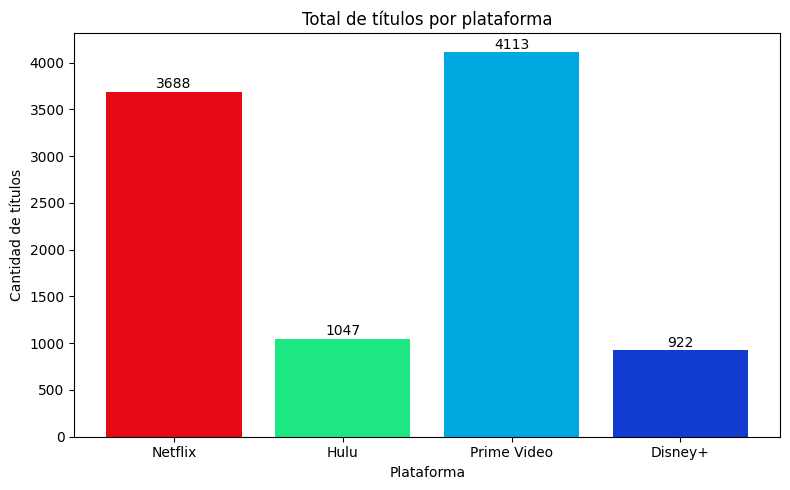

In [17]:
# Visualización - Gráfico 1. Total de títulos por plataforma.
import matplotlib.pyplot as plt

# Conteo total de títulos por plataforma (columnas binarias)
platform_counts = df[['netflix', 'hulu', 'prime_video', 'disney']].sum()

# Renombrar plataformas para mejor legibilidad
platform_counts.index = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']

# Colores representativos de cada plataforma
colors = [
    '#E50914',  # Netflix
    '#1CE783',  # Hulu
    '#00A8E1',  # Prime Video
    '#113CCF'   # Disney+
]

plt.figure(figsize=(8, 5))
bars = plt.bar(platform_counts.index, platform_counts.values, color=colors)

# Añadir etiquetas encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,                 # un poco de espacio vertical
        str(int(height)),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Total de títulos por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Cantidad de títulos")
plt.tight_layout()
plt.show()

El gráfico muestra de forma clara la diferencia en el número de títulos disponibles por plataforma.  
Prime Video presenta el mayor volumen de contenido, seguido por Netflix, mientras que Hulu y Disney+ cuentan con catálogos más reducidos.


### Gráfico 2 — Distribución de clasificación de edad por plataforma

Este gráfico muestra la distribución de las clasificaciones de edad del contenido disponible en cada plataforma, permitiendo comparar el perfil de audiencia al que se orienta cada servicio de streaming.


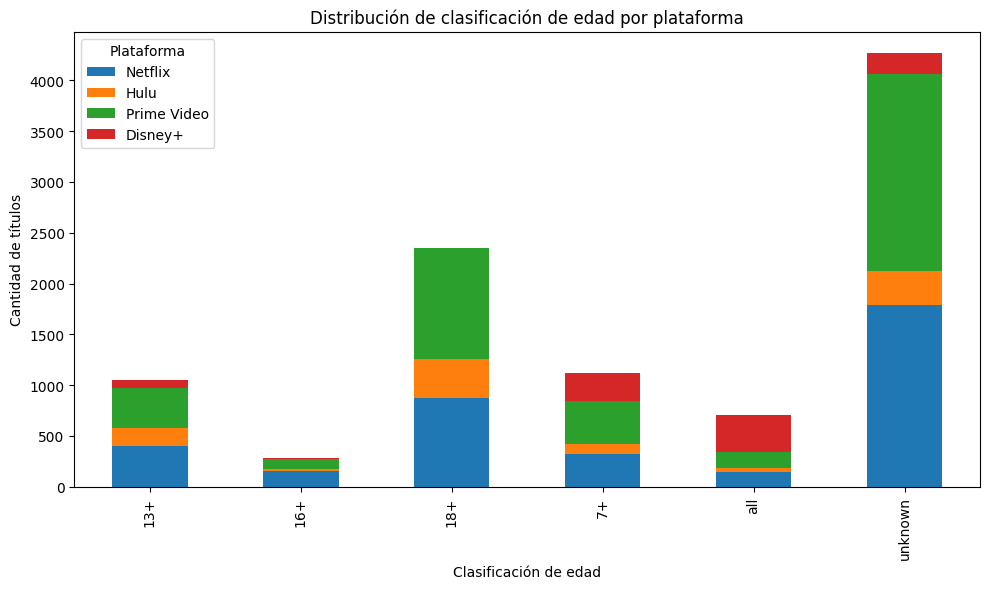

In [18]:
# Visualización - Gráfico 2. Distribución de clasificación de edad por plataforma.
import matplotlib.pyplot as plt

# Agrupar por clasificación de edad y sumar por plataforma
age_distribution = df.groupby('age')[['netflix', 'hulu', 'prime_video', 'disney']].sum()

# Renombrar columnas para mejor legibilidad
age_distribution.columns = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']

# Crear gráfico de barras apiladas
age_distribution.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Distribución de clasificación de edad por plataforma')
plt.xlabel('Clasificación de edad')
plt.ylabel('Cantidad de títulos')
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()


Disney+ concentra una mayor proporción de títulos con clasificaciones familiares, mientras que Netflix, Hulu y Prime Video presentan una mayor presencia de contenido orientado a audiencias adultas. Se observa además una proporción considerable de clasificaciones desconocidas, lo que representa una limitación del dataset.

### Gráfico 3 — Calificación promedio según Rotten Tomatoes por plataforma

Este gráfico compara la calificación promedio del contenido disponible en cada plataforma de streaming, permitiendo identificar diferencias en la recepción crítica entre los catálogos.


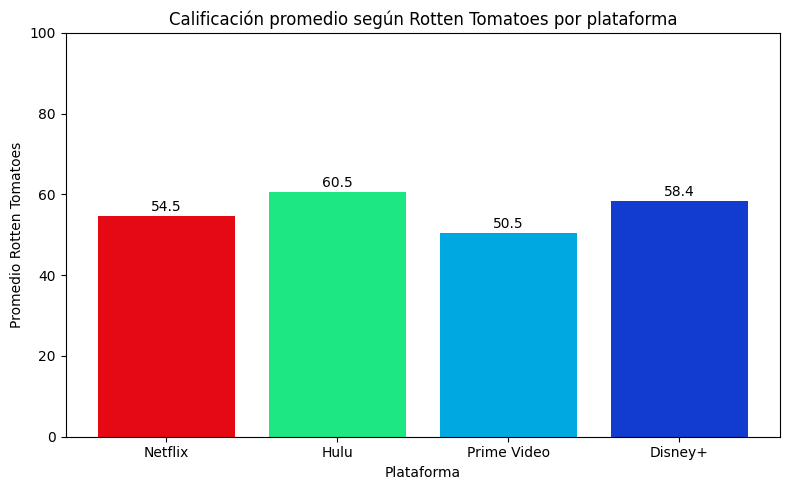

In [19]:
# Visualización - Gráfico 3. Calificación promedio de Rotten Tomatoes por plataforma.
import matplotlib.pyplot as plt

# Calcular promedio de Rotten Tomatoes por plataforma
avg_scores = {
    'Netflix': df.loc[df['netflix'] == 1, 'rotten_tomatoes'].mean(),
    'Hulu': df.loc[df['hulu'] == 1, 'rotten_tomatoes'].mean(),
    'Prime Video': df.loc[df['prime_video'] == 1, 'rotten_tomatoes'].mean(),
    'Disney+': df.loc[df['disney'] == 1, 'rotten_tomatoes'].mean()
}

platforms = list(avg_scores.keys())
scores = list(avg_scores.values())

colors = [
    '#E50914',  # Netflix
    '#1CE783',  # Hulu
    '#00A8E1',  # Prime Video
    '#113CCF'   # Disney+
]

plt.figure(figsize=(8,5))
bars = plt.bar(platforms, scores, color=colors)

# Etiquetas de valor sobre cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Calificación promedio según Rotten Tomatoes por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Promedio Rotten Tomatoes')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


Hulu y Disney+ presentan los promedios más altos, mientras que Netflix se ubica en un punto intermedio y Prime Video muestra el promedio más bajo, lo que sugiere una mayor variabilidad en la calidad de su catálogo. 

### Gráfico 4 — Top 10 películas mejor valoradas según Rotten Tomatoes

Este gráfico presenta las diez películas con mayor calificación según Rotten Tomatoes, permitiendo identificar títulos específicos que destacan por su alta recepción crítica.


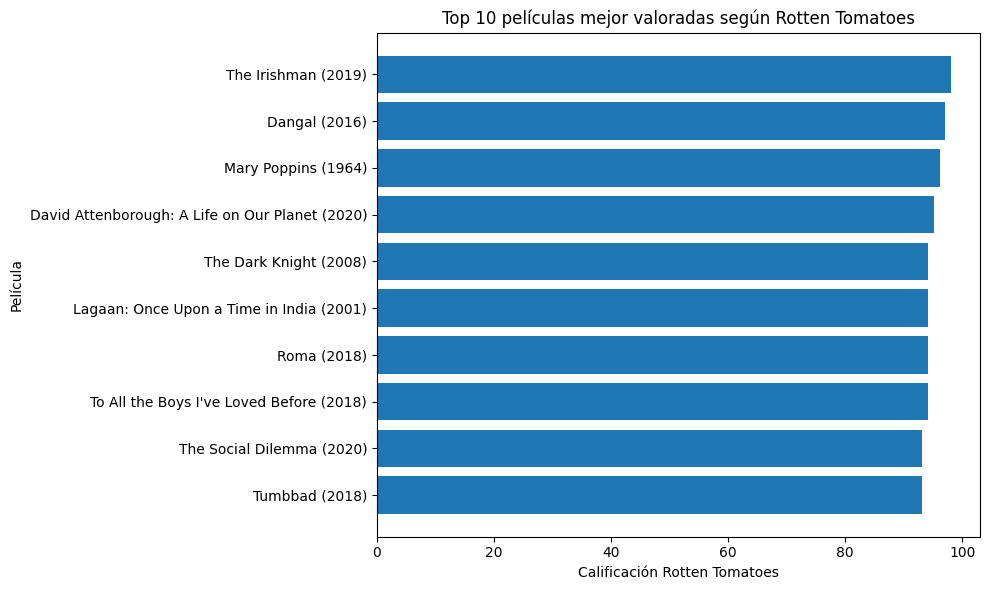

In [20]:
# Visualización - Gráfico 4. Top 10 películas mejor valoradas según Rotten Tomatoes.
import matplotlib.pyplot as plt

# Seleccionar Top 10 películas mejor valoradas
top_10 = (
    df[['title', 'year', 'rotten_tomatoes']]
    .dropna(subset=['rotten_tomatoes'])
    .sort_values(by='rotten_tomatoes', ascending=False)
    .head(10)
)

# Crear etiqueta con título y año
top_10['title_year'] = top_10['title'] + ' (' + top_10['year'].astype(str) + ')'

plt.figure(figsize=(10,6))
bars = plt.barh(
    top_10['title_year'],
    top_10['rotten_tomatoes']
)

plt.title('Top 10 películas mejor valoradas según Rotten Tomatoes')
plt.xlabel('Calificación Rotten Tomatoes')
plt.ylabel('Película')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Las películas mejor valoradas se concentran principalmente en títulos estrenados entre 2001 y 2020.  
La mayoría de los títulos presentes en el top 10 se encuentran disponibles en Netflix, lo que sugiere una mayor concentración de películas con alta recepción crítica en su catálogo.

### Gráfico 5 — Mapa de calor de correlaciones

Este gráfico explora la relación entre las variables numéricas disponibles en el dataset, con el objetivo de identificar posibles correlaciones entre el año de estreno y la calificación según Rotten Tomatoes.


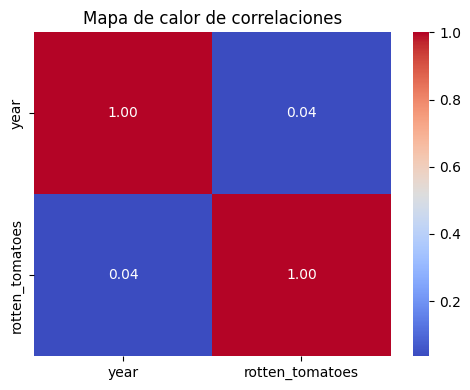

In [21]:
# Visualización - Mapa de calor de correlaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar variables numéricas relevantes
numeric_df = df[['year', 'rotten_tomatoes']].dropna()

plt.figure(figsize=(5,4))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Mapa de calor de correlaciones')
plt.tight_layout()
plt.show()


No se observan correlaciones fuertes entre el año de estreno y la calificación según Rotten Tomatoes.  
Esto sugiere que la antigüedad de una película no determina directamente su recepción crítica dentro de las variables disponibles. 

## Conclusiones

A lo largo de este análisis se exploró el catálogo de distintas plataformas de streaming a partir
de un dataset centrado en películas, evaluando aspectos como la cantidad de títulos disponibles,
la orientación por clasificación de edad y la recepción crítica según Rotten Tomatoes.

- Prime Video lidera en volumen de contenido, sugiriendo una estrategia centrada en amplitud.  
- Hulu y Disney+ presentan calificaciones promedio más altas, lo que apunta a mayor consistencia crítica.  
- Netflix combina un catálogo amplio con presencia significativa de películas altamente valoradas.  
- Disney+ se orienta claramente al público familiar, mientras que Netflix, Hulu y Prime Video tienen más contenido para adultos.  
- No se identificaron correlaciones fuertes entre el año de estreno y la calificación según Rotten Tomatoes.

Limitaciones: ausencia de métricas de popularidad y presencia de valores desconocidos en la clasificación de edad, lo que restringe el alcance de algunas conclusiones. Los resultados deben interpretarse como una aproximación descriptiva basada en la información disponible


## Nota final
Este análisis forma parte de un proyecto personal de aprendizaje en análisis de datos,
desarrollado con el objetivo de fortalecer habilidades en Python, limpieza de datos,
análisis exploratorio y visualización.